# Writing Your First (Hopefully Not) Transformer-Based Language Model

In this seminar, we're going to refresh our memory and implement a somewhat SoTA arcitecure pre 2022 that looks very similar to GPT-2 from (almost) absolute scratch.

First, there is a solution from a previous seminar for you on loading the data.

In [1]:
import json
import numpy as np

from jaxtyping import UInt32, Bool, Float32, BFloat16

TokenizedRow = dict[str, UInt32[np.typing.ArrayLike, "example_len"] | Bool[np.typing.ArrayLike, "example_len"]]


def load_list_of_dicts(path: str) -> list[dict[str, TokenizedRow]]:
    """
    Deserialize a file saved by save_list_of_dicts().
    """
    with np.load(path, allow_pickle=False) as z:
        meta = json.loads(z["_meta"].tobytes().decode("utf-8"))
        out: list[dict[str, np.ndarray]] = []
        for idx_map in meta:
            d: dict[str, np.ndarray] = {}
            for k, name in idx_map.items():
                d[k] = z[name]
            out.append(d)
    return out


data = load_list_of_dicts("dataset.npz")

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset

Inputs = UInt32[np.typing.ArrayLike, "seq_len"]
Labels = UInt32[np.typing.ArrayLike, "seq_len"]
PositionIds = UInt32[np.typing.ArrayLike, "seq_len"]
AttentionMask = Bool[np.typing.ArrayLike, "query_len key_len"]
LossMask = Bool[np.typing.ArrayLike, "seq_len"]
LMExample = dict[str, Inputs | Labels | PositionIds | AttentionMask | LossMask]


def make_attention_mask_from_positions(
    position_ids: UInt32[np.typing.ArrayLike, "seq_len"],
) -> Bool[np.typing.ArrayLike, "seq_len seq_len"]:
    """
    Creates an attention mask matrix from `position_ids`

    :param np.ndarray position_ids: An array representing the position IDs of tokens in a sequence.
        It should have a shape of (seq_len,).
    :return: An array representing the attention mask. It has a shape of (1, seq_len, seq_len).
        The elements of the attention mask are binary values indicating whether each token in
        the sequence should be attended to (True) or not (False).
    """
    seq_len = position_ids.size

    # Segment ID increments each time position counter resets to 0
    segment_ids = np.cumsum(position_ids == 0)

    # Causal mask: row ≥ col (lower triangular)
    indices = np.arange(seq_len)
    causal_mask = indices[:, None] >= indices

    # Same-segment mask: allow attention only within segments
    same_segment_mask = segment_ids[:, None] == segment_ids

    attention_mask = causal_mask & same_segment_mask
    return attention_mask


assert np.allclose(
    make_attention_mask_from_positions(np.array([0, 1, 2, 0, 1], dtype=np.uint32)),
    np.array(
        [
            [True, False, False, False, False],
            [True, True, False, False, False],
            [True, True, True, False, False],
            [False, False, False, True, False],
            [False, False, False, True, True],
        ]
    ),
)


class LMDataset(Dataset):
    def __init__(self, rows: list[TokenizedRow]):
        super().__init__()
        self.rows = rows

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, idx: int) -> LMExample:
        """
        Language modeling objective.
        tokens: are input tokens, all except the last one
        labels: target next tokens, all except the first one
        attention_mask: since we're doing causal language modeling
        loss_mask: whether loss should be calculated on specific `target` tokens
        position_ids: positions of input tokens
        """
        record = self.rows[idx]
        text = record["input_ids"]
        position_ids = record["position_ids"][:-1]
        loss_mask = record["loss_mask"][1:]
        attention_mask = torch.tensor(make_attention_mask_from_positions(position_ids))
        text = torch.from_numpy(text).long()
        labels = text[1:]
        tokens = text[:-1]
        loss_mask = torch.from_numpy(loss_mask).float()
        position_ids = torch.from_numpy(position_ids).long()

        return {
            "tokens": tokens.contiguous(),
            "labels": labels.contiguous(),
            "attention_mask": attention_mask,
            "loss_mask": loss_mask,
            "position_ids": position_ids,
        }


dataset = LMDataset(data)

In [3]:
from torch.utils.data import DataLoader

InputsBatch = UInt32[np.typing.ArrayLike, "bs seq_len"]
LabelsBatch = UInt32[np.typing.ArrayLike, "bs seq_len"]
PositionIdsBatch = UInt32[np.typing.ArrayLike, "bs seq_len"]
AttentionMaskBatch = Bool[np.typing.ArrayLike, "bs seq_len seq_len"]
LossMaskBatch = Bool[np.typing.ArrayLike, "bs seq_len"]
LMExampleBatch = dict[str, InputsBatch | LabelsBatch | PositionIdsBatch | AttentionMaskBatch | LossMaskBatch]


def collate_lm(batch: list[LMExample]) -> LMExampleBatch:
    """
    Stacks all the examples in the batch
    """
    keys = batch[0].keys()
    out: dict[str, torch.Tensor] = {}
    for k in keys:
        vals = [sample[k] for sample in batch]
        first_shape = vals[0].shape
        if any(v.shape != first_shape for v in vals[1:]):
            raise ValueError(f"Field {k!r} has non-uniform shapes in batch: {[v.shape for v in vals]}")
        out[k] = torch.stack(vals, dim=0)
    return out

## MLP

Multi-Layer Perceptron (MLP) or Feed-Forward Network (FFN) is a part of a transformer where most of the parameters are. It takes attention-produced representation of tokens and tries to make something useful out of it.

We're going to imlement an MLP from the legacy arcitectures. Today, it looks a bit differently (you'll se how in the next week) but before, it was simple two linear layers and the activation function between them followed by a dropout. The only interesting part here is the dimensions of the layers. The output dimension of the whole MLP always equals the input dimension. This means that the dimensions do not change whatsoever across all the LM layers and it can be parametrized by a single parameter `hidden_size`. Not sure if it's universally the case, technically, you can change the hidden size from layer to layer but in practice nobody does it and all the frameworks likely won't be able to express it. Anyway, the question is what the middle dimension is going to be. The industry standard was (and still kinda is) $4 \times \operatorname{hidden size}$.

In [4]:
ACTIVATION_FN = {
    "relu": F.relu,
    "gelu": F.gelu,
    "silu": F.silu,
    "sigmoid": F.sigmoid,
    "relu_squared": lambda x: torch.pow(F.relu(x), 2),
}

HiddenStates = Float32[torch.Tensor, "bs seq_len hidden_size"] | BFloat16[torch.Tensor, "bs seq_len hidden_size"]


class LegacyMLP(nn.Module):
    def __init__(
        self,
        hidden_size: int,
        activation: str = "gelu",
        intermediate_size: int | None = None,
        resid_pdrop: float = 0.1,
        add_bias_linear: bool = True,
    ):
        super().__init__()
        if intermediate_size is None:
            intermediate_size = hidden_size * 4

        self.activation = ...
        self.c_fc = ...
        self.c_proj = ...
        self.dropout = ...

    def forward(self, hidden_states: HiddenStates) -> HiddenStates:
        # Your code goes here
        return hidden_states

In [5]:
mlp = LegacyMLP(hidden_size=768)

x = torch.ones((2, 1024, 768))
assert x.shape == torch.Size([2, 1024, 768])

## Attention

We can move forward to implementing Attention. There might be different actual implementation, e.g., FlashAttention, but they all end up doing the same math. Because of that, it's useful to have a protocol on which an attention is going to operate, we'll call it `AttentionBackend`.

Then, we need to implement actual Attention in raw PyTorch. The formula is from the book:
$$
\operatorname{Attention}(Q, K, V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_j}}V\right),
$$

Usually, all the $Q$s, $K$s, and $V$s are being obtained by a single linear transformation of hidden states and by then splitting the result into desired slices.

The only difference that is important to language modeling and usually not indicated in the textbook formulas is we need a causual attention mask: $i$-th query only looks at keys with indices less than $i$.

In [6]:
import math
from typing import Protocol

Query = Float32[torch.Tensor, "bs n_heads query_len dim"] | BFloat16[torch.Tensor, "bs n_heads query_len dim"]
Key = Float32[torch.Tensor, "bs n_heads key_len dim"] | BFloat16[torch.Tensor, "bs n_heads key_len dim"]
Value = Float32[torch.Tensor, "bs n_heads key_len dim"] | BFloat16[torch.Tensor, "bs n_heads key_len dim"]
AttentionMaskBatch = Bool[torch.Tensor, "bs seq_len seq_len"]
AttentionScores = Float32[torch.Tensor, "bs n_heads query_len key_len"]
AttentionOutput = tuple[Query, AttentionScores | None]


class AttentionBackend(Protocol):
    """
    Pluggable attention kernel.
    Implementations receive per-head q, k, v and return the per-head context.
    Shapes:
      q, k, v: [bs, n_heads, q_len, head_dim], [bs, n_heads, k_len, head_dim], [bs, n_heads, k_len, head_dim]
      key_padding_mask: [bs, k_len] with True=keep, False=masked (or None)
    """

    def __call__(
        self,
        q: Query,
        k: Key,
        v: Value,
        *,
        is_causal: bool,
        key_padding_mask: AttentionMaskBatch | None,
        attn_dropout_p: float,
        training: bool,
        need_weights: bool,
    ) -> AttentionOutput: ...


class EagerAttention(AttentionBackend):
    def __call__(
        self,
        q: Query,
        k: Key,
        v: Value,
        *,
        attention_mask: AttentionMaskBatch | None,
        attn_dropout_p: float,
        training: bool,
        need_weights: bool,
    ) -> AttentionOutput:
        bs, n_heads, query_length, dim = q.shape
        _, _, key_length, _ = k.shape

        q = q.to(torch.float32)
        k = k.to(torch.float32)
        v = v.to(torch.float32)

        scale = 1.0 / math.sqrt(dim)
        attn_scores = ...

        if attention_mask is not None:
            # Fill attention scores with -inf on the positions of tokens we shouldn't look at
            attn_scores = ...

        # Apply softmax
        attn_probs = ...
        attn_probs = torch.nan_to_num(attn_probs)

        if attn_dropout_p > 0 and training:
            attn_probs = F.dropout(attn_probs, p=attn_dropout_p)

        # Multiply by V
        context = torch.matmul(...)
        return context, (attn_probs if need_weights else None)


attn = EagerAttention()

torch.manual_seed(0)

bs, n_heads, seq_len, d = 1, 2, 4, 2
q = torch.arange(bs * n_heads * seq_len * d, dtype=torch.float32).reshape(bs, n_heads, seq_len, d)
k = torch.arange(bs * n_heads * seq_len * d, dtype=torch.float32).reshape(bs, n_heads, seq_len, d)
v = torch.ones_like(k)

attention_mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool))
attention_mask = attention_mask.unsqueeze(0).expand(bs, -1, -1)

context, attn_probs = attn(
    q=q,
    k=k,
    v=v,
    attention_mask=attention_mask,
    attn_dropout_p=0.0,
    training=False,
    need_weights=True,
)

print("Attention mask:\n", attention_mask[0].int())
print("Attention probs (head 0):\n", attn_probs[0, 0])
print("Context output (head-merged):\n", context)

masked_positions = ~attention_mask
assert torch.allclose(
    attn_probs.masked_select(masked_positions[:, None, :, :]),
    torch.zeros_like(attn_probs.masked_select(masked_positions[:, None, :, :])),
), "Masked (future) positions must have zero probability"

row_sums = attn_probs.sum(dim=-1)
assert torch.allclose(row_sums, torch.ones_like(row_sums)), "Each query's probs must sum to 1"

Attention mask:
 tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]], dtype=torch.int32)
Attention probs (head 0):
 tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [8.4861e-04, 9.9915e-01, 0.0000e+00, 0.0000e+00],
        [8.8037e-12, 2.9671e-06, 1.0000e+00, 0.0000e+00],
        [1.1137e-24, 1.0744e-16, 1.0366e-08, 1.0000e+00]])
Context output (head-merged):
 tensor([[[[1.0000, 1.0000],
          [1.0000, 1.0000],
          [1.0000, 1.0000],
          [1.0000, 1.0000]],

         [[1.0000, 1.0000],
          [1.0000, 1.0000],
          [1.0000, 1.0000],
          [1.0000, 1.0000]]]])


## Causal Attention Layer

We have heads now.

$$
\operatorname{MultiHead}(Q, K, V) = \operatorname{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O,\text{ where } \operatorname{head}_i = \operatorname{Attention}(QW_i^Q, KW_i^K, V_i^W).
$$

In [7]:
ATTN_BACKENDS = {
    "eager": EagerAttention(),
}


class CausalSelfAttention(nn.Module):
    def __init__(
        self,
        hidden_size: int,
        num_heads: int,
        head_dim: int | None = None,
        qkv_bias: bool = False,
        out_bias: bool = False,
        attn_dropout_p: float = 0.0,
        resid_dropout_p: float = 0.1,
        backend: str = "eager",
    ):
        super().__init__()
        assert hidden_size % num_heads == 0 or head_dim is not None, "hidden_size % num_heads == 0 or set head_dim"

        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = head_dim if head_dim is not None else hidden_size // num_heads
        self.qkv_bias = qkv_bias
        self.out_bias = out_bias
        self.attn_dropout_p = attn_dropout_p
        self.resid_dropout_p = resid_dropout_p

        proj_in = 3 * self.num_heads * self.head_dim
        self.qkv_proj = nn.Linear(self.hidden_size, proj_in, bias=qkv_bias)
        self.out_proj = nn.Linear(self.num_heads * self.head_dim, self.hidden_size, bias=out_bias)
        self.residual_dropout = nn.Dropout(self.resid_dropout_p)
        self.backend = ATTN_BACKENDS[backend]

    def _split_heads(
        self, x: Float32[torch.Tensor, "bs seq_len dim"]
    ) -> Float32[torch.Tensor, "bs n_heads seq_len dim"]:
        bs, seq, _ = x.shape
        x = x.view(bs, seq, self.num_heads, self.head_dim).transpose(1, 2)
        return x

    def _merge_heads(
        self, x: Float32[torch.Tensor, "bs n_heads seq_len dim"]
    ) -> Float32[torch.Tensor, "bs seq_len dim"]:
        bs, h, seq, d = x.shape
        x = x.transpose(1, 2).contiguous().view(bs, seq, h * d)
        return x

    def forward(
        self,
        hidden_states: HiddenStates,
        *,
        attention_mask: AttentionMaskBatch | None = None,
        need_weights: bool = False,
    ) -> AttentionOutput:
        bs, q_len, _ = hidden_states.shape
        device = hidden_states.device
        dtype = hidden_states.dtype

        # A linear layer over hidden states
        qkv = ...

        # split the result into q, k, and v matrices
        q, k, v = ...

        # Extract heads out of them (take a look at `split_heads`)
        q = ...
        k = ...
        v = ...
        k_len_total = k.shape[2]

        # Run attention!
        context, attn_weights = ...

        # We need to merge heads back
        out = ...

        # Apply out projection
        out = ...
        # Dropout
        out = ...
        return out


def test_causal_self_attention_block_triangular_uniform_attn() -> None:
    torch.manual_seed(0)

    bs, seq_len, hidden_size, n_heads = 1, 4, 8, 2
    head_dim = hidden_size // n_heads

    # Input: at position t, all features = t
    x = torch.arange(seq_len, dtype=torch.float32).repeat(hidden_size).view(hidden_size, seq_len).T
    x = x.unsqueeze(0)  # [1, seq_len, hidden_size]

    # Causal mask: lower-triangular
    attention_mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool)).unsqueeze(0)

    attn = CausalSelfAttention(
        hidden_size=hidden_size,
        num_heads=n_heads,
        head_dim=head_dim,
        qkv_bias=False,
        out_bias=False,
        attn_dropout_p=0.0,
        resid_dropout_p=0.0,
        backend="eager",
    )

    # 1) Force Q = 0 -> logits = 0 -> uniform probs over allowed keys
    # 2) Make V pick x[..., 0] (the token index t), repeat across all v dims
    # 3) Make out_proj identity so merged heads pass through unchanged
    with torch.no_grad():
        attn.qkv_proj.weight.zero_()
        if attn.qkv_proj.bias is not None:
            attn.qkv_proj.bias.zero_()

        H = hidden_size
        # V block is rows [2H : 3H); set those rows to select input column 0
        attn.qkv_proj.weight[2 * H : 3 * H, 0] = 1.0  # v = x[..., 0] repeated

        attn.out_proj.weight.zero_()
        if attn.out_proj.bias is not None:
            attn.out_proj.bias.zero_()
        attn.out_proj.weight.copy_(torch.eye(H))

    out = attn(x, attention_mask=attention_mask)

    assert out.shape == (bs, seq_len, hidden_size)
    assert torch.isfinite(out).all()

    expected = torch.tensor([0.0, 0.5, 1.0, 1.5], dtype=torch.float32)
    for t in range(seq_len):
        row = out[0, t, :]
        assert torch.allclose(row, torch.full_like(row, expected[t]), atol=1e-6), f"pos {t}: {row[:4]} vs {expected[t]}"

    print("✅ CausalSelfAttention block-triangular test passed.")


test_causal_self_attention_block_triangular_uniform_attn()

✅ CausalSelfAttention block-triangular test passed.


## GPT Block

It's time to assemble the "layer" in our model. The two main parts are obvious: first Attention, then MLP. However, the non-obvious part is where to place LayerNorms. There are two main approaches:
1. **Pre-LayerNorm**: `(save residual) -> ln -> attn -> + residual -> (save residual) -> ln -> mlp -> + residual`.
2. **Post-LayerNorm**: `(save residual) -> attn -> + residual -> ln -> (save residual) -> mlp -> + residual -> ln`.

The industry kinda converged to using **Pre-LayerNorm**, the original Attention Is All You Need used Post-LayerNorm but it was later shown to be unstable. There is also a third variant that Gemma uses, they have something like this:

`(save residual) -> rmsnorm -> attn -> rmsnorm -> + residual -> (save residual) -> rmsnorm -> mlp  -> rmsnorm -> + residual`

We're going to implement pre-layernorm here.

In [8]:
class GPTBlock(nn.Module):
    def __init__(
        self,
        hidden_size: int,
        num_heads: int,
        head_dim: int | None = None,
        qkv_bias: bool = False,
        out_bias: bool = False,
        activation: str = "gelu",
        intermediate_size: int | None = None,
        attn_dropout_p: float = 0.0,
        resid_pdrop: float = 0.1,
        add_bias_linear: bool = True,
        layer_norm_epsilon: float = 1e-5,
        attention_backend: str = "eager",
    ):
        super().__init__()

        self.ln1 = ...
        self.attn = ...
        self.ln2 = ...
        self.mlp = ...

    def forward(self, hidden_states: HiddenStates, attention_mask: AttentionMaskBatch | None) -> HiddenStates:
        residual = hidden_states
        # Attention pass
        # Your code goes here

        residual = hidden_states
        # MLP pass
        # Your code goes here

        return hidden_states


def test_gpt_block_identity_pass():
    torch.manual_seed(0)

    bs, seq_len, hidden_size, n_heads = 1, 4, 8, 2
    x = torch.arange(bs * seq_len * hidden_size, dtype=torch.float32).reshape(bs, seq_len, hidden_size)

    # Causal block-triangular mask [bs, seq, seq] (True = keep)
    attention_mask = torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool)).unsqueeze(0)

    block = GPTBlock(
        hidden_size=hidden_size,
        num_heads=n_heads,
        qkv_bias=False,
        out_bias=False,
        activation="gelu",
        intermediate_size=None,
        attn_dropout_p=0.0,
        resid_pdrop=0.0,
        add_bias_linear=True,
        layer_norm_epsilon=1e-5,
        attention_backend="eager",
    )
    block.eval()  # disable dropout for determinism

    # Make block act as identity: attention path -> 0, MLP path -> 0
    with torch.no_grad():
        # Attention projections
        block.attn.qkv_proj.weight.zero_()
        if block.attn.qkv_proj.bias is not None:
            block.attn.qkv_proj.bias.zero_()
        block.attn.out_proj.weight.zero_()
        if block.attn.out_proj.bias is not None:
            block.attn.out_proj.bias.zero_()

        # MLP projections
        block.mlp.c_fc.weight.zero_()
        if block.mlp.c_fc.bias is not None:
            block.mlp.c_fc.bias.zero_()
        block.mlp.c_proj.weight.zero_()
        if block.mlp.c_proj.bias is not None:
            block.mlp.c_proj.bias.zero_()

    out = block(x.clone(), attention_mask=attention_mask)

    assert out.shape == (bs, seq_len, hidden_size), f"bad shape: {out.shape}"
    assert out.dtype == x.dtype, f"dtype changed: {out.dtype} vs {x.dtype}"
    # Exact identity (since both sublayers output zeros and only residuals remain)
    assert torch.allclose(out, x), "block should behave like identity under this setup"

    # Gradient check: d(sum(out))/d(x) should be ones
    x_req = x.clone().requires_grad_(True)
    out2 = block(x_req, attention_mask=attention_mask)
    loss = out2.sum()
    loss.backward()
    assert torch.allclose(x_req.grad, torch.ones_like(x_req)), "grad through residual path should be 1"
    print("✅ GPTBlock identity test passed.")


test_gpt_block_identity_pass()

✅ GPTBlock identity test passed.


## Positional Encoding

We're currently lacking an important component: positional encodings.

### Learned

The very baseline that GPT-2 uses. Treat the position the same way we treat token ID and assign an embedding. The hidden states that are passed to the first layer are then the sum of token and position embeddings.

In [9]:
class LearnedPositionalEncoding(nn.Module):
    """
    Classic learned positional embeddings (additive).
    position_ids: [bs, seq_len] of positions (0..max_pos-1).
    """

    def __init__(self, hidden_size: int, max_position_embeddings: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.max_position_embeddings = max_position_embeddings
        self.embed = nn.Embedding(max_position_embeddings, hidden_size)

    def forward(
        self,
        hidden_states: HiddenStates,
        position_ids: PositionIdsBatch | None = None,
    ) -> HiddenStates:
        bs, seq_len, _ = hidden_states.shape
        device = hidden_states.device
        dtype = hidden_states.dtype

        if position_ids is None:
            position_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(bs, -1)

        position_ids = position_ids.clamp_(min=0, max=self.max_position_embeddings - 1)

        pos = ...
        hidden_states = ...
        return hidden_states.to(dtype)


def test_learned_positional_encoding():
    bs, seq_len, hidden = 1, 3, 6
    x = torch.zeros(bs, seq_len, hidden, dtype=torch.float32)
    position_ids = torch.tensor([[0, 1, 2]], dtype=torch.long)

    pe = LearnedPositionalEncoding(hidden_size=hidden, max_position_embeddings=16)

    # Make a single known offset for position 1, dim 3
    with torch.no_grad():
        pe.embed.weight.zero_()
        pe.embed.weight[1, 3] = 2.5

    y = pe(x, position_ids=position_ids)

    assert y.shape == x.shape
    # pos 0 untouched (all zeros), pos 1 has +2.5 at dim 3
    assert torch.allclose(y[0, 0], torch.zeros(hidden))
    assert y[0, 1, 3].item() == 2.5


test_learned_positional_encoding()

### Cosine

Fixed-frequency (sinusoidal) features. For model dim `d`, position `p`, channel index `i` and base `B` (e.g., `10_000`):

$$
\theta_i = \frac{p}{B^{\frac{2\lfloor i/2 \rfloor}{d}}},\quad
\text{PE}[p,i] =
\begin{cases}
\cos(\theta_i), & i \text{ even} \\
\sin(\theta_i), & i \text{ odd}
\end{cases}
$$

Hidden input: $h_0[p] = \text{tok\_emb}[p] + \text{PE}[p]$.

In [10]:
class CosinePositionalEncoding(nn.Module):
    """
    Cosine/sinusoidal positional encoding (additive, no learned params).
    Standard Transformer formulation: even dims = sin, odd dims = cos.
    """

    def __init__(self, hidden_size: int, max_position_embeddings: int, base: float = 10_000.0):
        super().__init__()
        assert hidden_size % 2 == 0, "sinusoidal PE expects even hidden_size"
        self.hidden_size = hidden_size
        self.max_position_embeddings = max_position_embeddings
        self.base = base

        pos = torch.arange(max_position_embeddings, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(0, hidden_size, 2, dtype=torch.float32).unsqueeze(0)
        angle = pos / (base ** (i / hidden_size))

        pe = torch.zeros(max_position_embeddings, hidden_size, dtype=torch.float32)
        pe[:, 0::2] = ...
        pe[:, 1::2] = ...
        self.register_buffer("pe", pe, persistent=False)

    def forward(
        self,
        hidden_states: HiddenStates,
        position_ids: PositionIdsBatch | None = None,
    ) -> HiddenStates:
        bs, seq_len, _ = hidden_states.shape
        device = hidden_states.device
        dtype = hidden_states.dtype

        if position_ids is None:
            position_ids = torch.arange(seq_len, device=device).unsqueeze(0).expand(bs, -1)

        position_ids = position_ids.clamp_(min=0, max=self.max_position_embeddings - 1)
        pos = ...
        hidden_states = ...
        return hidden_states.to(dtype)


def test_cosine_positional_encoding():
    bs, seq_len, hidden = 1, 4, 6  # hidden must be even for sinusoidal
    x = torch.zeros(bs, seq_len, hidden, dtype=torch.float32)
    position_ids = torch.arange(seq_len).unsqueeze(0)

    pe = CosinePositionalEncoding(hidden_size=hidden, max_position_embeddings=64)

    y = pe(x, position_ids=position_ids)

    assert y.shape == x.shape
    # At position 0: sin = 0 on even dims, cos = 1 on odd dims
    assert torch.allclose(y[0, 0, 0::2], torch.zeros(hidden // 2), atol=1e-6)
    assert torch.allclose(y[0, 0, 1::2], torch.ones(hidden // 2), atol=1e-6)
    # Different positions should yield different encodings
    assert not torch.allclose(y[0, 1], y[0, 0])


test_cosine_positional_encoding()

# The GPT

We now need to create the following:
1. Embedding layer (with dropout)
2. `n_layers` GPT blocks
3. Final LayerNorm
4. A single unembedding (LM Head) linear layer from hidden states back to vocabulary

In [11]:
from pydantic import BaseModel
from typing import Literal


class GPTConfig(BaseModel):
    vocab_size: int
    hidden_size: int
    num_heads: int
    n_layers: int
    max_position_embeddings: int | None = None
    position_encoding_base: float = 10_000.0
    head_dim: int | None = None
    qkv_bias: bool = False
    out_bias: bool = False
    activation: Literal["gelu", "relu", "silu", "sigmoid", "relu_squared"] = "gelu"
    position_encoding: Literal["learned", "cosine"] = "cosine"
    intermediate_size: int | None = None
    embed_dropout_p: float = 0.0
    attn_dropout_p: float = 0.0
    resid_pdrop: float = 0.1
    add_bias_linear: bool = True
    layer_norm_epsilon: float = 1e-5
    attention_backend: Literal["eager"] = "eager"

In [20]:
Logits = Float32[torch.Tensor, "bs seq_len vocab_size"] | BFloat16[torch.Tensor, "bs seq_len vocab_size"]


class GPTModel(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()

        self.embedding = ...
        if config.position_encoding == "learned":
            self.position_encoding = LearnedPositionalEncoding(config.hidden_size, config.max_position_embeddings)
        elif config.position_encoding == "cosine":
            self.position_encoding = CosinePositionalEncoding(
                config.hidden_size, config.max_position_embeddings, config.position_encoding_base
            )

        self.embedding_dropout = ...

        self.blocks = ...

        self.final_layernorm = ...
        self.lm_head = ...

    def forward(
        self,
        tokens: InputsBatch,
        position_ids: PositionIdsBatch,
        attention_mask: AttentionMaskBatch | None = None,
        loss_mask: LossMaskBatch | None = None,
        labels: LabelsBatch | None = None,
        return_loss: bool = False,
    ) -> Logits | tuple[Logits, torch.Tensor]:
        # Your code goes here
        logits = ...

        if not return_loss:
            return logits

        assert labels is not None, "Labels must be provided when return_loss=True"
        vocab_size = logits.size(-1)
        logits_flat = logits.view(-1, vocab_size)
        labels_flat = labels.view(-1)

        loss = ...

        if loss_mask is not None:
            loss = ...
        else:
            loss = ...

        return logits, loss


def test_gpt_model():
    loader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=True,
        drop_last=True,
        num_workers=0,
        pin_memory=False,
        collate_fn=collate_lm,
    )

    config = GPTConfig(
        vocab_size=50257,
        hidden_size=32,
        num_heads=2,
        n_layers=4,
        max_position_embeddings=1024,
        position_encoding_base=10_000.0,
        activation="gelu",
        position_encoding="cosine",
        embed_dropout_p=0.1,
        attn_dropout_p=0.1,
        resid_pdrop=0.1,
        add_bias_linear=False,
        layer_norm_epsilon=1e-5,
    )

    model = GPTModel(config)
    model.eval()
    batch = next(iter(loader))
    with torch.no_grad():
        logits = model(**batch)
    assert logits.shape == torch.Size([1, 1024, 50257])

    logits, loss = model(**batch, return_loss=True)
    loss.backward()
    assert logits.shape == torch.Size([1, 1024, 50257])
    assert loss.shape == torch.Size([])


test_gpt_model()

Let's train the model and see how it goes.

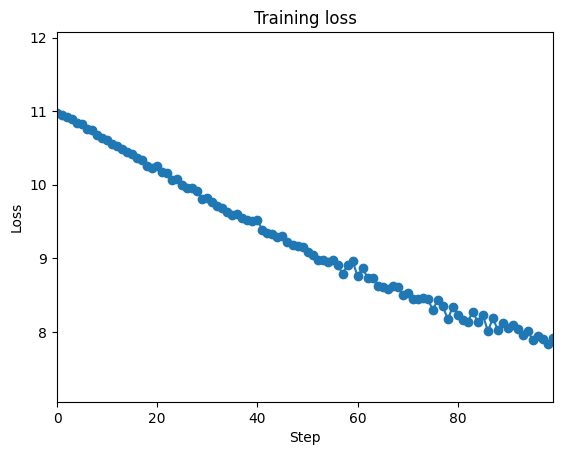

In [24]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


plt.ion()  # turn on interactive mode

fig, ax = plt.subplots()
(line,) = ax.plot([], [], marker="o")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training loss")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
display(fig)


def draw(loss_history: list[float]) -> None:
    # update data
    line.set_xdata(range(len(loss_history)))
    line.set_ydata(loss_history)

    # rescale axes
    ax.set_xlim(0, len(loss_history) - 1)
    ax.set_ylim(min(loss_history) * 0.9, max(loss_history) * 1.1)

    # redraw
    clear_output(wait=True)
    display(fig)
    plt.pause(0.001)  # let matplotlib breathe


def train(
    model: nn.Module, optimizer: torch.optim.Optimizer, dataloader: torch.utils.data.DataLoader, n_steps: int
) -> list[float]:
    loss_history = []
    data_iter = iter(dataloader)
    model.train()
    for step in range(n_steps):
        # Your code goes here
        batch = next(data_iter)
        logits, loss = ...
        # Your code goes here
        loss_history.append(loss.detach().item())
        draw(loss_history)

        # Your code goes here
    model.eval()
    return loss_history


config = GPTConfig(
    vocab_size=50257,
    hidden_size=32,
    num_heads=2,
    n_layers=4,
    max_position_embeddings=1024,
    position_encoding_base=10_000.0,
    activation="gelu",
    position_encoding="cosine",
    embed_dropout_p=0.1,
    attn_dropout_p=0.1,
    resid_pdrop=0.1,
    add_bias_linear=False,
    layer_norm_epsilon=1e-5,
)

model = GPTModel(config)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=False,
    collate_fn=collate_lm,
)

loss_history = train(model=model, optimizer=optimizer, dataloader=loader, n_steps=100)
assert loss_history[-1] < 8.0